# Multi-slide analysis and score transfer (Colon Day 9)

## Overview

This tutorial demonstrates CoPro's **multi-slide analysis** and **score transfer** capabilities using colon organoid Day 9 data. At Day 9, the tissue exhibits severe inflammation with heterogeneous disease progression across different regions. CoPro detects a **disease progression axis** that correlates with independently derived mucosal neighborhood (MU) labels — in particular, **MU8** marks the most severely inflamed niche.

When multiple tissue slides are available, CoPro can:

1. Learn co-progression patterns from a **reference slide**
2. **Transfer** the learned gene weights to new slides
3. Compare co-progression patterns across biological replicates

**Plots produced:**
1. Cell types on reference slide
2. MU labels on reference slide
3. Reference slide cell scores in situ
4. Disease scores by MU label (boxplot)
5. Cell type proportions along the disease axis
6. Top immune genes (bar chart)
7. Transferred scores across all slides
8. MU labels on target slide
9. Transfer consistency (normalized correlation)
10. Alternative: joint multi-slide CoPro

## 1. Load packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import copro as cp

print(f"copro version: {cp.__version__}")

copro version: 0.1.1


## 2. Download and load data

In [2]:
dat = cp.copro_download_data("colon_d9")

expr = dat["normalizedData"].values.astype(float) if isinstance(dat["normalizedData"], pd.DataFrame) else dat["normalizedData"].astype(float)
location = dat["locationData"] if isinstance(dat["locationData"], pd.DataFrame) else pd.DataFrame(dat["locationData"])
meta = dat["metaData"] if isinstance(dat["metaData"], pd.DataFrame) else pd.DataFrame(dat["metaData"])
cell_types = np.asarray(dat["cellTypes"]).ravel()
slide_id = np.asarray(dat["slideID"]).ravel()
selected_slides = list(np.unique(slide_id))  # or dat["selectedSlides"] if available

if isinstance(dat["normalizedData"], pd.DataFrame):
    gene_names = list(dat["normalizedData"].columns)
else:
    gene_names = [f"gene_{i}" for i in range(expr.shape[1])]

if "x" not in location.columns:
    location.columns = ["x", "y"] + list(location.columns[2:])

print(f"Total cells: {expr.shape[0]}, Genes: {expr.shape[1]}")
print(f"Slides: {selected_slides}")
for s in selected_slides:
    print(f"  {s}: {np.sum(slide_id == s)} cells")

Using cached file: /Users/zhenmiao/.copro/data/copro_colon_d9.rds


Total cells: 21436, Genes: 940
Slides: [np.str_('062221_D9_m3_2_slice_1'), np.str_('062221_D9_m3_2_slice_2'), np.str_('062221_D9_m3_2_slice_3')]
  062221_D9_m3_2_slice_1: 7242 cells
  062221_D9_m3_2_slice_2: 6627 cells
  062221_D9_m3_2_slice_3: 7567 cells


## 3. Visualize the tissue

### Cell types

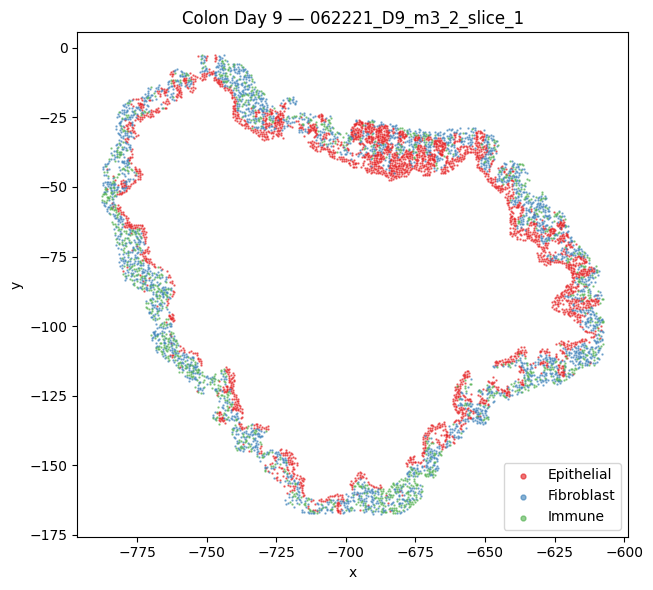

In [3]:
ct_colors = {"Epithelial": "#E41A1C", "Fibroblast": "#377EB8", "Immune": "#4DAF4A"}
ref_slide = selected_slides[0]
tar_slides = selected_slides[1:]

ref_mask = slide_id == ref_slide

fig, ax = plt.subplots(figsize=(7, 6))
for ct, color in ct_colors.items():
    sel = ref_mask & (cell_types == ct)
    ax.scatter(location.loc[sel, "x"], location.loc[sel, "y"],
               s=0.5, alpha=0.6, color=color, label=ct)
ax.set_aspect("equal")
ax.set_title(f"Colon Day 9 — {ref_slide}")
ax.legend(markerscale=5, loc="lower right")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()

### Mucosal neighborhood (MU) labels

**MU8** marks the most severely inflamed niche, while MU1–3 are grouped as relatively normal crypt neighborhoods.

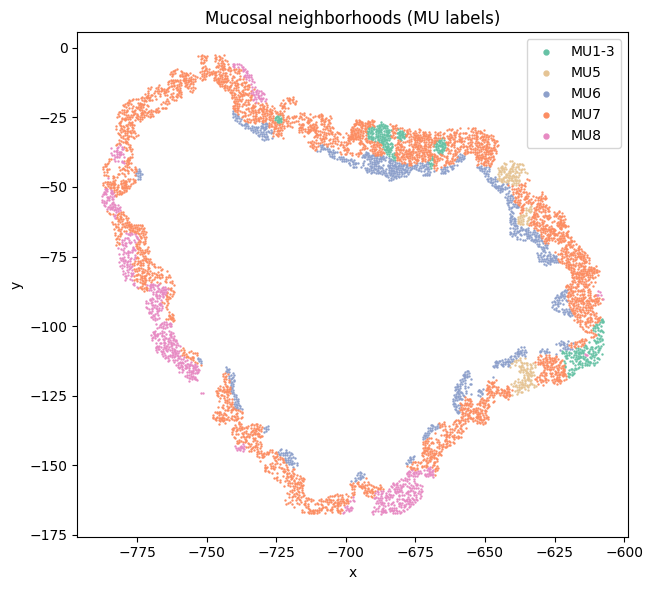

In [4]:
mu_all = meta["Leiden_neigh"].values.astype(str)
mu_grouped = mu_all.copy()
mu_grouped[np.isin(mu_all, ["MU1", "MU11"])] = "MU1-3"

mu_show = ["MU1-3", "MU5", "MU6", "MU7", "MU8"]
mu_colors = {"MU1-3": "#66C2A5", "MU5": "#E5C494", "MU6": "#8DA0CB",
             "MU7": "#FC8D62", "MU8": "#E78AC3"}

fig, ax = plt.subplots(figsize=(7, 6))
for mu in mu_show:
    sel = ref_mask & (mu_grouped == mu)
    if sel.sum() > 0:
        ax.scatter(location.loc[sel, "x"], location.loc[sel, "y"],
                   s=0.5, color=mu_colors[mu], label=mu)
ax.set_aspect("equal")
ax.set_title("Mucosal neighborhoods (MU labels)")
ax.legend(markerscale=5)
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()

## 4. Strategy: Reference + target slides

We use the first slide as the **reference** to learn co-progression patterns, then transfer scores to the other slides.

In [5]:
CELL_TYPES = ["Epithelial", "Fibroblast", "Immune"]
SIGMA_VALUES = [0.005, 0.01, 0.02, 0.05, 0.1]

print(f"Reference slide: {ref_slide}")
print(f"Target slides: {tar_slides}")

Reference slide: 062221_D9_m3_2_slice_1
Target slides: [np.str_('062221_D9_m3_2_slice_2'), np.str_('062221_D9_m3_2_slice_3')]


## 5. Run CoPro on the reference slide

In [6]:
ref_idx = slide_id == ref_slide

ref_obj = cp.CoProSingle(
    normalized_data=expr[ref_idx],
    location_data=location.loc[ref_idx].reset_index(drop=True),
    meta_data=meta.loc[ref_idx].reset_index(drop=True),
    cell_types=cell_types[ref_idx],
)
ref_obj = cp.subset_data(ref_obj, CELL_TYPES)
ref_obj = cp.compute_pca(ref_obj, n_pca=40)
ref_obj = cp.compute_distance(ref_obj)
ref_obj = cp.compute_kernel_matrix(ref_obj, sigma_values=SIGMA_VALUES)
ref_obj = cp.run_skr_cca(ref_obj, scale_pcs=True, n_cc=2)
ref_obj = cp.compute_normalized_correlation(ref_obj)
ref_obj = cp.compute_gene_and_cell_scores(ref_obj)
ref_obj = cp.compute_regression_gene_scores(ref_obj)

sigma_opt = ref_obj.sigma_value_choice
print(f"\nReference pipeline complete. sigma = {sigma_opt}")

Running SkrCCA for sigma = 0.005
Convergence reached at iteration 9 (max_diff=5.219e-06)
  Component convergence at iteration 26 (max_diff=7.950e-06)
Running SkrCCA for sigma = 0.01
Convergence reached at iteration 10 (max_diff=7.960e-06)
  Component convergence at iteration 10 (max_diff=5.535e-06)
Running SkrCCA for sigma = 0.02


Convergence reached at iteration 10 (max_diff=4.082e-06)
  Component convergence at iteration 9 (max_diff=6.414e-06)
Running SkrCCA for sigma = 0.05
Convergence reached at iteration 8 (max_diff=2.968e-06)
  Component convergence at iteration 9 (max_diff=2.761e-06)
Running SkrCCA for sigma = 0.1
Convergence reached at iteration 7 (max_diff=4.999e-06)
  Component convergence at iteration 7 (max_diff=2.795e-06)
Calculating spectral norms (may take a while)...


Finished calculating spectral norms.
Regression gene scores computed for sigma=0.005, Epithelial
Regression gene scores computed for sigma=0.005, Fibroblast
Regression gene scores computed for sigma=0.005, Immune
Regression gene scores computed for sigma=0.01, Epithelial
Regression gene scores computed for sigma=0.01, Fibroblast
Regression gene scores computed for sigma=0.01, Immune
Regression gene scores computed for sigma=0.02, Epithelial
Regression gene scores computed for sigma=0.02, Fibroblast
Regression gene scores computed for sigma=0.02, Immune
Regression gene scores computed for sigma=0.05, Epithelial
Regression gene scores computed for sigma=0.05, Fibroblast
Regression gene scores computed for sigma=0.05, Immune
Regression gene scores computed for sigma=0.1, Epithelial
Regression gene scores computed for sigma=0.1, Fibroblast
Regression gene scores computed for sigma=0.1, Immune

Reference pipeline complete. sigma = 0.1


### Reference slide cell scores in situ

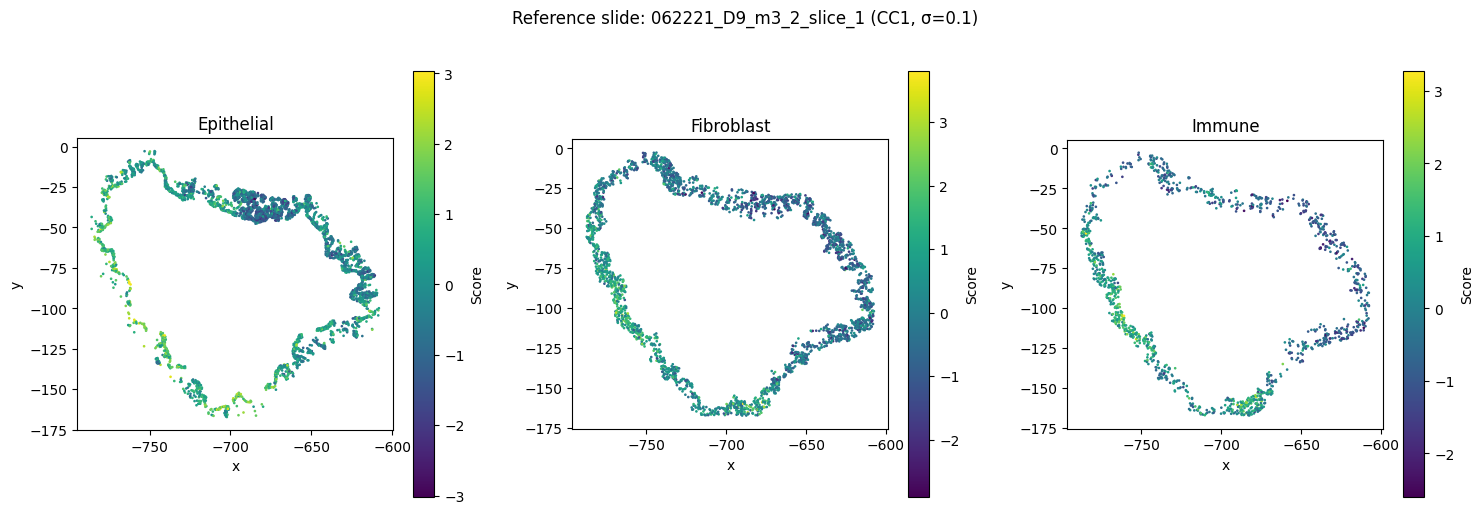

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, ct in enumerate(CELL_TYPES):
    mask = ref_obj.cell_types_sub == ct
    loc = ref_obj.location_data_sub.loc[mask]
    scores = ref_obj.cell_scores[f"cellScores|sigma{sigma_opt}|{ct}"][:, 0]
    sc = axes[i].scatter(loc["x"].values, loc["y"].values,
                          c=scores, cmap="viridis", s=0.8)
    plt.colorbar(sc, ax=axes[i], label="Score")
    axes[i].set_title(ct)
    axes[i].set_aspect("equal")
    axes[i].set_xlabel("x")
    axes[i].set_ylabel("y")

fig.suptitle(f"Reference slide: {ref_slide} (CC1, σ={sigma_opt})", y=1.02)
plt.tight_layout()
plt.show()

### Disease axis vs MU labels

The CoPro disease axis should correlate with MU labels, with MU8 cells showing the highest scores.

/var/folders/zb/hv2qjx4n0sj0pggrzy4pw7hw0000gn/T/ipykernel_58482/2732993900.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,


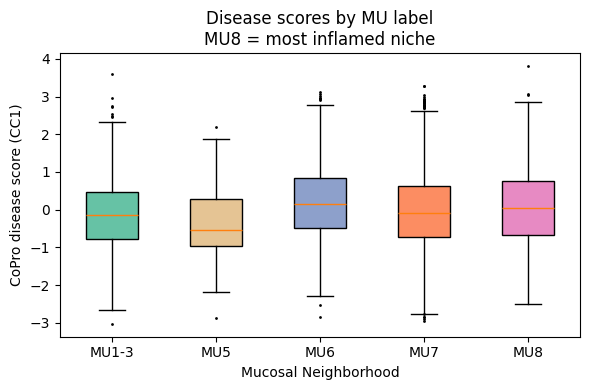

In [8]:
# Gather cell scores for all cell types on the reference slide
ref_scores = []
ref_mu_labels = []

ref_meta_sub = meta.loc[ref_idx].reset_index(drop=True)
ref_ct_sub = cell_types[ref_idx]
sub_mask = np.isin(ref_ct_sub, CELL_TYPES)
ref_meta_sub = ref_meta_sub.loc[sub_mask].reset_index(drop=True)

for ct in CELL_TYPES:
    cs_key = f"cellScores|sigma{sigma_opt}|{ct}"
    ref_scores.append(ref_obj.cell_scores[cs_key][:, 0])

all_scores = np.concatenate(ref_scores)

# Get MU labels for subsetted cells
mu_ref = ref_meta_sub["Leiden_neigh"].values.astype(str)
mu_ref_grouped = mu_ref.copy()
mu_ref_grouped[np.isin(mu_ref, ["MU1", "MU11"])] = "MU1-3"

# Filter to the MU groups we want to show
keep = np.isin(mu_ref_grouped, mu_show)

box_data = []
box_labels = []
for mu in ["MU1-3", "MU5", "MU6", "MU7", "MU8"]:
    sel = (mu_ref_grouped == mu) & keep
    if sel.sum() > 0:
        box_data.append(all_scores[sel])
        box_labels.append(mu)

fig, ax = plt.subplots(figsize=(6, 4))
bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,
                flierprops={"markersize": 1})
for patch, mu in zip(bp["boxes"], box_labels):
    patch.set_facecolor(mu_colors[mu])
ax.set_xlabel("Mucosal Neighborhood")
ax.set_ylabel("CoPro disease score (CC1)")
ax.set_title("Disease scores by MU label\nMU8 = most inflamed niche")
plt.tight_layout()
plt.show()

### Cell type proportions along the disease axis

As disease severity increases, the cell type composition shifts — immune cell proportion increases while epithelial proportion decreases.

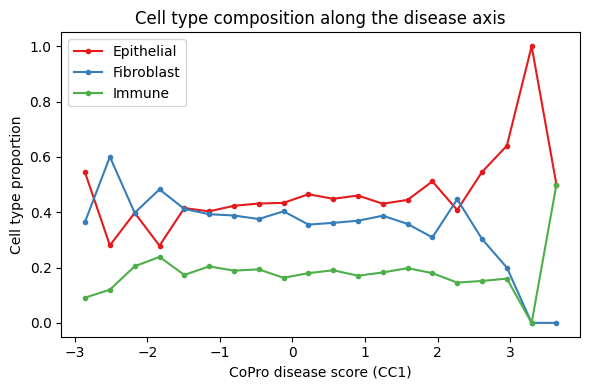

In [9]:
# Gather cell types for subsetted cells
all_ct_sub = ref_obj.cell_types_sub

# Bin cells by disease score
n_bins = 20
bins = pd.cut(all_scores, bins=n_bins)
bin_mids = [(b.left + b.right) / 2 for b in bins]

score_df = pd.DataFrame({
    "score": all_scores,
    "cell_type": all_ct_sub,
    "bin_mid": bin_mids,
})

# Compute proportions per bin
prop_rows = []
for mid, grp in score_df.groupby("bin_mid"):
    for ct in CELL_TYPES:
        prop_rows.append({
            "score_mid": mid,
            "cell_type": ct,
            "proportion": (grp["cell_type"] == ct).mean(),
        })
prop_df = pd.DataFrame(prop_rows)

fig, ax = plt.subplots(figsize=(6, 4))
for ct, color in ct_colors.items():
    sub = prop_df[prop_df["cell_type"] == ct].sort_values("score_mid")
    ax.plot(sub["score_mid"], sub["proportion"], "o-", color=color, label=ct, markersize=3)

ax.set_xlabel("CoPro disease score (CC1)")
ax.set_ylabel("Cell type proportion")
ax.set_title("Cell type composition along the disease axis")
ax.legend()
plt.tight_layout()
plt.show()

### Top genes associated with the disease axis

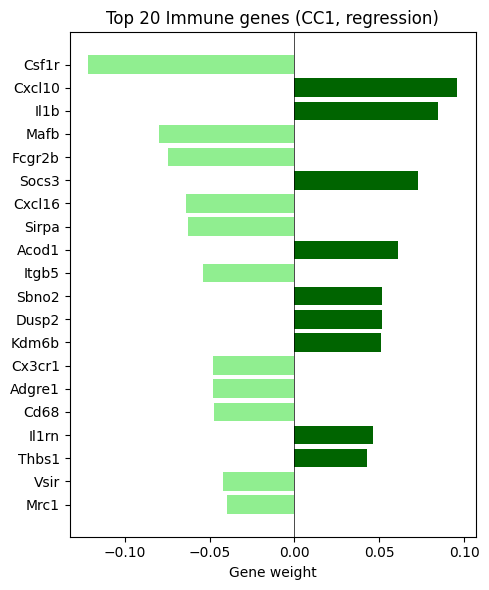

In [10]:
gs_key = f"geneScores|sigma{sigma_opt}|Immune"
gs_imm = ref_obj.gene_scores_regression[gs_key][:, 0]

gene_df = pd.DataFrame({"gene": gene_names, "weight": gs_imm})
gene_df = gene_df.reindex(gene_df["weight"].abs().sort_values(ascending=False).index)
top = gene_df.head(20)

colors = ["darkgreen" if w > 0 else "lightgreen" for w in top["weight"]]

fig, ax = plt.subplots(figsize=(5, 6))
ax.barh(top["gene"][::-1], top["weight"][::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Gene weight")
ax.set_title("Top 20 Immune genes (CC1, regression)")
plt.tight_layout()
plt.show()

## 6. Create target CoPro objects

In [11]:
tar_objs = {}
for ts in tar_slides:
    t_idx = slide_id == ts
    t_obj = cp.CoProSingle(
        normalized_data=expr[t_idx],
        location_data=location.loc[t_idx].reset_index(drop=True),
        meta_data=meta.loc[t_idx].reset_index(drop=True),
        cell_types=cell_types[t_idx],
    )
    t_obj = cp.subset_data(t_obj, CELL_TYPES)
    t_obj = cp.compute_pca(t_obj, n_pca=40)
    t_obj = cp.compute_distance(t_obj)
    t_obj = cp.compute_kernel_matrix(t_obj, sigma_values=SIGMA_VALUES)
    tar_objs[ts] = t_obj
    print(f"Target {ts}: {t_idx.sum()} cells")

Target 062221_D9_m3_2_slice_2: 6627 cells


Target 062221_D9_m3_2_slice_3: 7567 cells


## 7. Transfer scores

In [12]:
tar_scores = {}
for ts in tar_slides:
    tar_scores[ts] = cp.get_transfer_cell_scores(
        ref_obj=ref_obj,
        tar_obj=tar_objs[ts],
        sigma_choice=sigma_opt,
        gene_score_type="regression",
    )
    print(f"Transferred scores to {ts}")

Transferring scores for cell type 'Epithelial' (2985 target cells, 940 genes)


Quantile normalization done: 2985 target cells, 940 features.
  retaining 940 genes for CC_1 with threshold 0.0
  retaining 940 genes for CC_2 with threshold 0.0
Transferring scores for cell type 'Fibroblast' (2306 target cells, 940 genes)
Quantile normalization done: 2306 target cells, 940 features.


  retaining 940 genes for CC_1 with threshold 0.0
  retaining 940 genes for CC_2 with threshold 0.0
Transferring scores for cell type 'Immune' (1336 target cells, 940 genes)
Quantile normalization done: 1336 target cells, 940 features.
  retaining 940 genes for CC_1 with threshold 0.0
  retaining 940 genes for CC_2 with threshold 0.0
Transferred scores to 062221_D9_m3_2_slice_2
Transferring scores for cell type 'Epithelial' (1724 target cells, 940 genes)


Quantile normalization done: 1724 target cells, 940 features.
  retaining 940 genes for CC_1 with threshold 0.0
  retaining 940 genes for CC_2 with threshold 0.0
Transferring scores for cell type 'Fibroblast' (2941 target cells, 940 genes)


Quantile normalization done: 2941 target cells, 940 features.
  retaining 940 genes for CC_1 with threshold 0.0
  retaining 940 genes for CC_2 with threshold 0.0
Transferring scores for cell type 'Immune' (2902 target cells, 940 genes)
Quantile normalization done: 2902 target cells, 940 features.


  retaining 940 genes for CC_1 with threshold 0.0
  retaining 940 genes for CC_2 with threshold 0.0
Transferred scores to 062221_D9_m3_2_slice_3


## 8. Visualize transferred scores across all slides

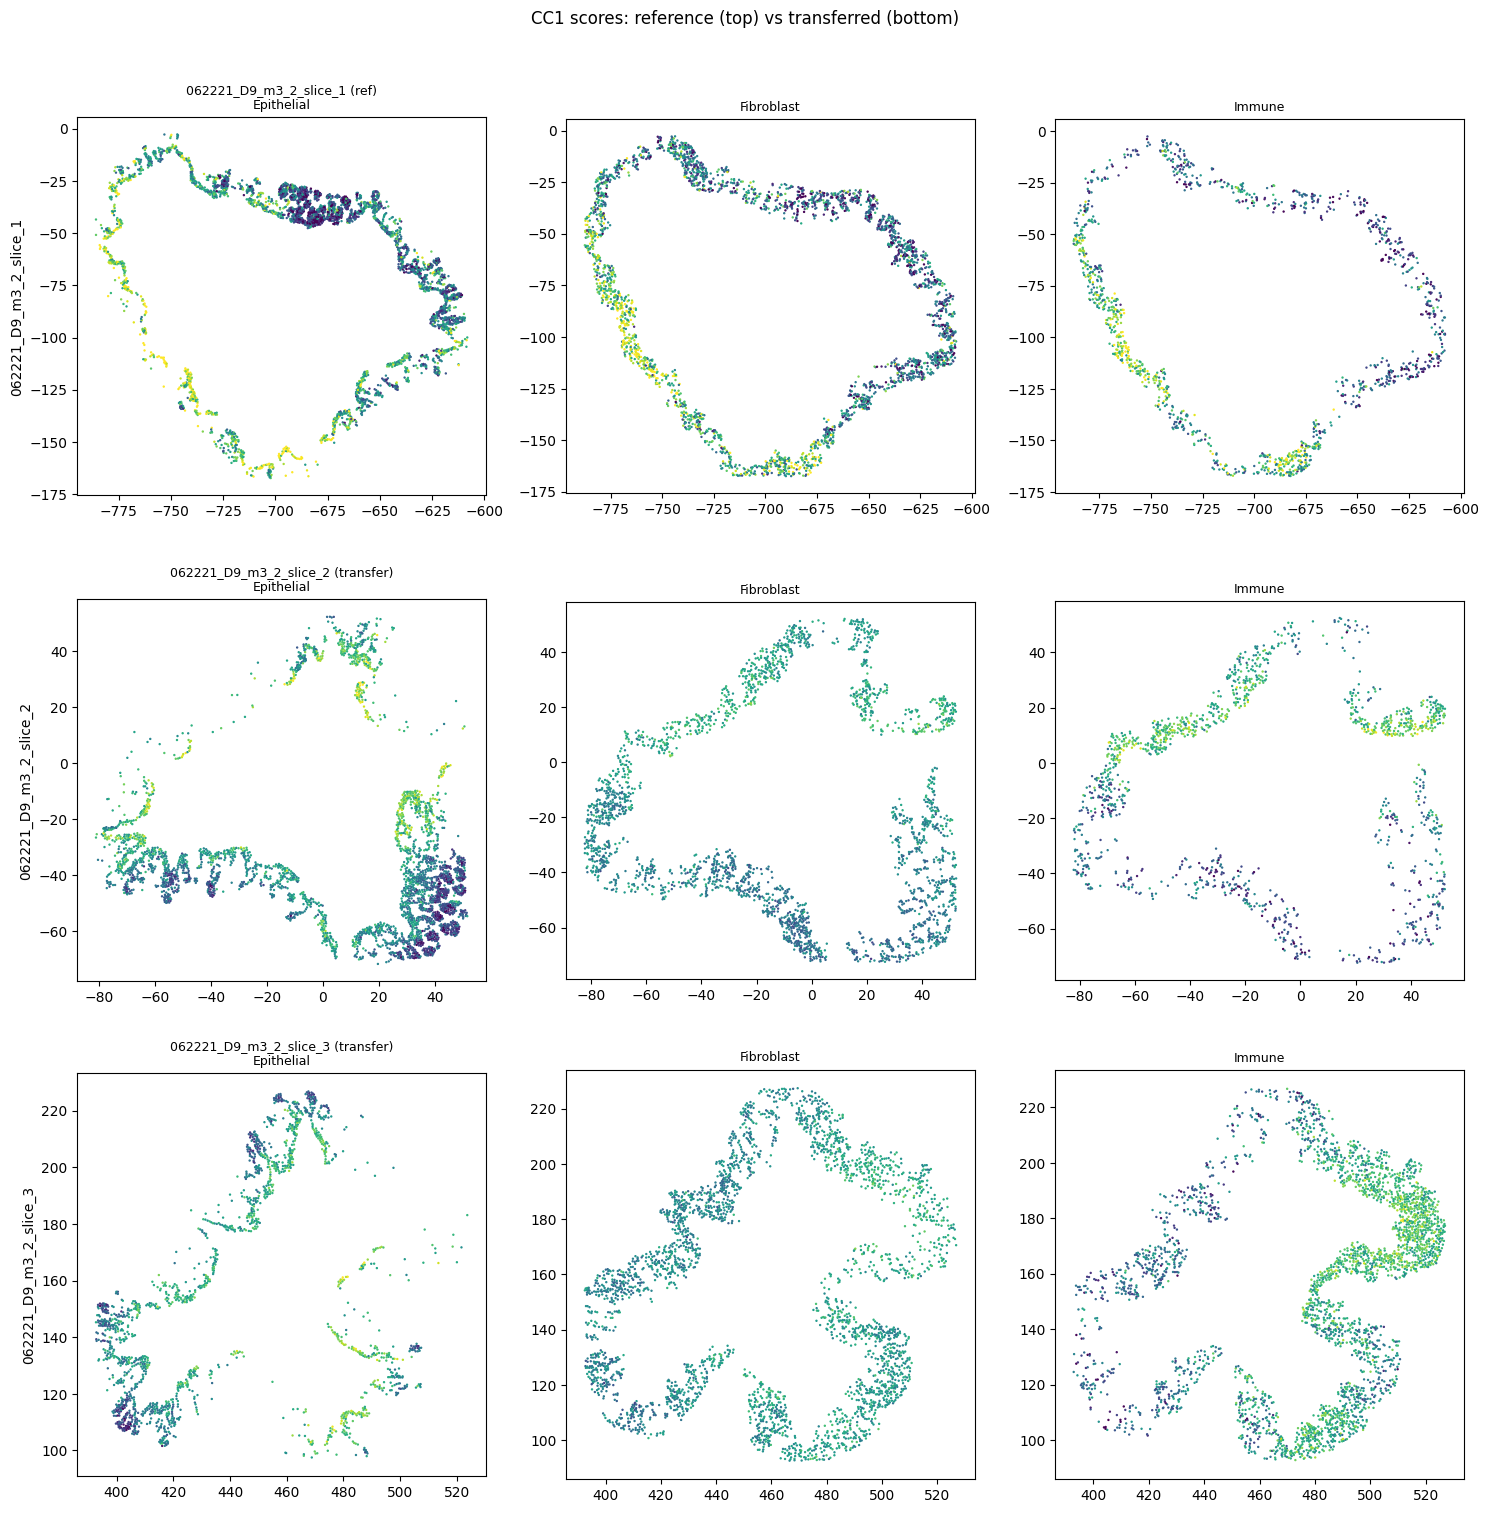

In [13]:
n_slides = 1 + len(tar_slides)
fig, axes = plt.subplots(n_slides, 3, figsize=(15, 5 * n_slides))

# Determine global color range
all_s = []
for ct in CELL_TYPES:
    all_s.append(ref_obj.cell_scores[f"cellScores|sigma{sigma_opt}|{ct}"][:, 0])
    for ts in tar_slides:
        all_s.append(tar_scores[ts][ct][:, 0])
vmin, vmax = np.percentile(np.concatenate(all_s), [2, 98])

# Reference slide (row 0)
for j, ct in enumerate(CELL_TYPES):
    ax = axes[0][j]
    mask = ref_obj.cell_types_sub == ct
    loc = ref_obj.location_data_sub.loc[mask]
    scores = ref_obj.cell_scores[f"cellScores|sigma{sigma_opt}|{ct}"][:, 0]
    sc = ax.scatter(loc["x"].values, loc["y"].values,
                     c=scores, cmap="viridis", s=0.5, vmin=vmin, vmax=vmax)
    ax.set_title(f"{ct}" if j > 0 else f"{ref_slide} (ref)\n{ct}", fontsize=9)
    ax.set_aspect("equal")
    if j == 0:
        ax.set_ylabel(ref_slide, fontsize=10)

# Target slides
for row_i, ts in enumerate(tar_slides, 1):
    t_obj = tar_objs[ts]
    for j, ct in enumerate(CELL_TYPES):
        ax = axes[row_i][j]
        mask = t_obj.cell_types_sub == ct
        loc = t_obj.location_data_sub.loc[mask]
        scores = tar_scores[ts][ct][:, 0]
        sc = ax.scatter(loc["x"].values, loc["y"].values,
                         c=scores, cmap="viridis", s=0.5, vmin=vmin, vmax=vmax)
        ax.set_title(ct if j > 0 else f"{ts} (transfer)\n{ct}", fontsize=9)
        ax.set_aspect("equal")
        if j == 0:
            ax.set_ylabel(ts, fontsize=10)

fig.suptitle("CC1 scores: reference (top) vs transferred (bottom)", y=1.01)
plt.tight_layout()
plt.show()

### MU labels on target slide

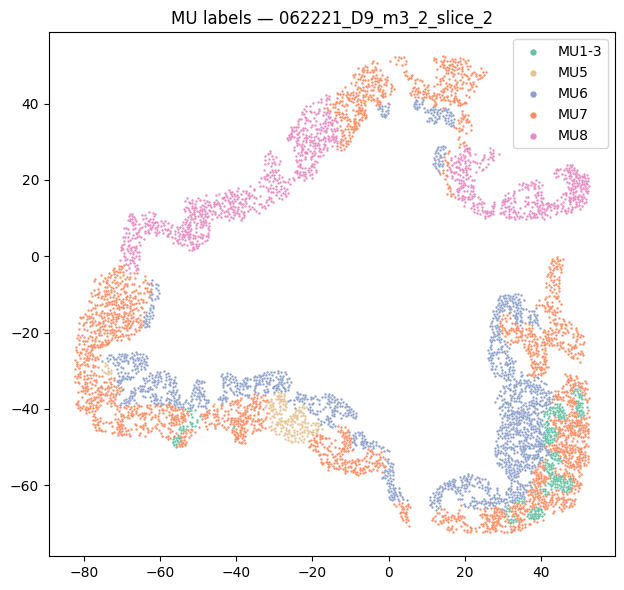

In [14]:
ts = tar_slides[0]
tar1_mask = slide_id == ts

tar1_mu = meta.loc[tar1_mask, "Leiden_neigh"].values.astype(str)
tar1_mu_grouped = tar1_mu.copy()
tar1_mu_grouped[np.isin(tar1_mu, ["MU1", "MU11"])] = "MU1-3"

fig, ax = plt.subplots(figsize=(7, 6))
for mu in mu_show:
    sel = tar1_mu_grouped == mu
    if sel.sum() > 0:
        ax.scatter(location.loc[tar1_mask].reset_index(drop=True).loc[sel, "x"],
                   location.loc[tar1_mask].reset_index(drop=True).loc[sel, "y"],
                   s=0.5, color=mu_colors[mu], label=mu)
ax.set_aspect("equal")
ax.set_title(f"MU labels — {ts}")
ax.legend(markerscale=5)
plt.tight_layout()
plt.show()

## 9. Assess transfer consistency

Compare the normalized correlation between the reference and transferred slides to assess whether the co-progression pattern is consistent.

In [15]:
# Reference normalized correlation
print("Reference normalized correlation:")
for sname, df in ref_obj.normalized_correlation.items():
    sub = df[df["sigma"] == sigma_opt]
    if len(sub) > 0:
        print(sub.to_string(index=False))

# Target normalized correlations
for ts in tar_slides:
    print(f"\nTarget {ts} transferred normalized correlation:")
    tar_nc = cp.get_transfer_norm_corr(
        tar_obj=tar_objs[ts],
        transfer_cell_scores=tar_scores[ts],
        sigma_choice=sigma_opt,
    )
    print(tar_nc.to_string(index=False))

Reference normalized correlation:
 sigma cell_type_1 cell_type_2  CC_index  normalized_correlation
   0.1  Epithelial  Fibroblast         1                0.175457
   0.1  Epithelial  Fibroblast         2                0.096794
   0.1  Epithelial      Immune         1                0.201662
   0.1  Epithelial      Immune         2                0.030557
   0.1  Fibroblast      Immune         1                0.347138
   0.1  Fibroblast      Immune         2                0.128149

Target 062221_D9_m3_2_slice_2 transferred normalized correlation:
 sigma cell_type_1 cell_type_2  CC_index  normalized_correlation
   0.1  Epithelial  Fibroblast         1                0.145444
   0.1  Epithelial  Fibroblast         2                0.006084
   0.1  Epithelial      Immune         1                0.161271
   0.1  Epithelial      Immune         2               -0.086258
   0.1  Fibroblast      Immune         1                0.406530
   0.1  Fibroblast      Immune         2              

 sigma cell_type_1 cell_type_2  CC_index  normalized_correlation
   0.1  Epithelial  Fibroblast         1                0.120582
   0.1  Epithelial  Fibroblast         2               -0.039847
   0.1  Epithelial      Immune         1                0.139848
   0.1  Epithelial      Immune         2               -0.039692
   0.1  Fibroblast      Immune         1                0.338401
   0.1  Fibroblast      Immune         2                0.207907


High transferred normalized correlations indicate that the co-progression pattern learned from the reference generalizes well to independent slides.

## 10. Alternative: Multi-slide CoPro

For joint analysis across all slides simultaneously, use `create_copro` with `slide_id`.

In [16]:
multi_obj = cp.create_copro(
    normalized_data=expr,
    location_data=location,
    meta_data=meta,
    cell_types=cell_types,
    slide_id=slide_id,
)
multi_obj = cp.subset_data(multi_obj, CELL_TYPES)
multi_obj = cp.compute_pca(multi_obj, n_pca=40)
multi_obj = cp.compute_distance(multi_obj)
multi_obj = cp.compute_kernel_matrix(multi_obj, sigma_values=SIGMA_VALUES)
multi_obj = cp.run_skr_cca(multi_obj, scale_pcs=True, n_cc=2)
multi_obj = cp.compute_normalized_correlation(multi_obj)
multi_obj = cp.compute_gene_and_cell_scores(multi_obj)

print(f"\nMulti-slide pipeline complete. sigma = {multi_obj.sigma_value_choice}")
print("The multi-slide approach optimizes CCA weights jointly across all slides.")

Running SkrCCA (multi) for sigma = 0.005
Convergence reached at iteration 7 (max_diff=6.419e-06)


  Component convergence at iteration 19 (max_diff=8.111e-06)
Running SkrCCA (multi) for sigma = 0.01
Convergence reached at iteration 8 (max_diff=3.660e-06)


  Component convergence at iteration 38 (max_diff=9.477e-06)
Running SkrCCA (multi) for sigma = 0.02
Convergence reached at iteration 8 (max_diff=2.201e-06)


  Component convergence at iteration 33 (max_diff=7.608e-06)
Running SkrCCA (multi) for sigma = 0.05
Convergence reached at iteration 8 (max_diff=1.717e-06)


  Component convergence at iteration 18 (max_diff=8.814e-06)
Running SkrCCA (multi) for sigma = 0.1
Convergence reached at iteration 8 (max_diff=2.346e-06)


  Component convergence at iteration 20 (max_diff=8.644e-06)
Calculating spectral norms (multi-slide)...


Finished spectral norms.

Multi-slide pipeline complete. sigma = 0.1
The multi-slide approach optimizes CCA weights jointly across all slides.


## References

**CoPro method:**  
Miao Z. et al. *CoPro: Unsupervised detection of coordinated spatial progressions in spatial transcriptomics* (in preparation).